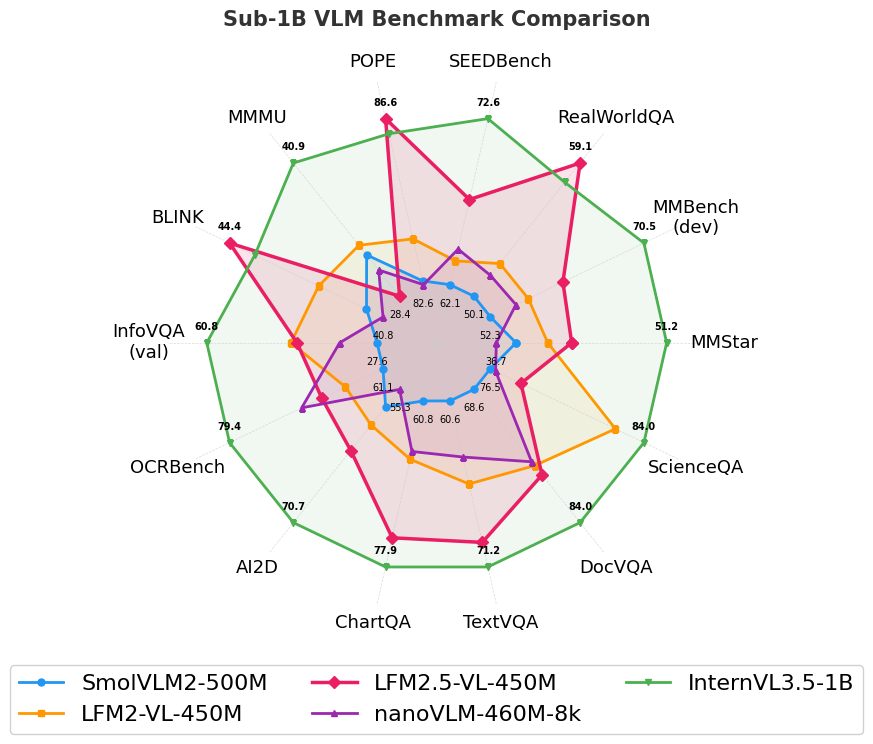

Saved to radar_sub1b_comparison_normalized.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt

benchmarks = [
    'MMStar', 'MMBench\n(dev)', 'RealWorldQA', 'SEEDBench',
    'POPE', 'MMMU', 'BLINK', 'InfoVQA\n(val)', 'OCRBench',
    'AI2D', 'ChartQA', 'TextVQA', 'DocVQA', 'ScienceQA'
]

smolvlm2  = [38.4, 52.3, 50.1, 62.1, 82.7, 32.3, 41.2, 27.6, 61.1, 57.3, 60.8, 60.6, 68.6, 76.5]
lfm2      = [41.1, 56.8, 52.3, 63.6, 83.7, 33.2, 42.3, 44.4, 65.6, 59.4, 66.8, 65.9, 77.4, 82.6]
lfm25     = [43.13, 60.91, 59.08, 67.47, 86.56, 28.44, 44.35, 43.22, 68.4, 62.34, 74.88, 69.63, 78.47, 77.99]
nanovlm   = [36.73, 55.33, 51.50, 64.34, 82.61, 30.89, 40.82, 34.91, 70.8, 55.28, 66.00, 64.18, 76.96, 76.75]
internvl  = [51.2, 70.53, 57.78, 72.57, 86.20, 40.89, 43.77, 60.82, 79.4, 70.66, 77.88, 71.20, 83.98, 83.99]

models = {
    'SmolVLM2-500M':   {'scores': smolvlm2, 'color': '#2196F3', 'marker': 'o', 'lw': 2.0, 'ms': 5},
    'LFM2-VL-450M':    {'scores': lfm2,     'color': '#FF9800', 'marker': 's', 'lw': 2.0, 'ms': 5},
    'LFM2.5-VL-450M':  {'scores': lfm25,    'color': '#E91E63', 'marker': 'D', 'lw': 2.5, 'ms': 6},
    'nanoVLM-460M-8k': {'scores': nanovlm,  'color': '#9C27B0', 'marker': '^', 'lw': 2.0, 'ms': 5},
    'InternVL3.5-1B':  {'scores': internvl, 'color': '#4CAF50', 'marker': 'v', 'lw': 2.0, 'ms': 5},
}

# Normalize each benchmark to [0, 1] using min/max across all models (with padding)
all_scores = np.array([m['scores'] for m in models.values()])
mins = all_scores.min(axis=0)
maxs = all_scores.max(axis=0)
spread = maxs - mins
spread[spread == 0] = 1

pad_bottom = spread * 0.35
pad_top = spread * 0.15
norm_min = mins - pad_bottom
norm_max = maxs + pad_top
norm_spread = norm_max - norm_min

normalized = {}
for name, m in models.items():
    normalized[name] = ((np.array(m['scores']) - norm_min) / norm_spread).tolist()

N = len(benchmarks)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

for name in normalized:
    normalized[name] = normalized[name] + [normalized[name][0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for name, m in models.items():
    nvals = normalized[name]
    fill_alpha = 0.12 if name == 'LFM2.5-VL-450M' else 0.08
    ax.plot(angles, nvals, f'{m["marker"]}-', linewidth=m['lw'], color=m['color'],
            label=name, markersize=m['ms'])
    ax.fill(angles, nvals, alpha=fill_alpha, color=m['color'])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(benchmarks, fontsize=13, fontweight='medium')

ax.set_yticks([])
ax.set_ylim(0, 1.05)

ax.spines['polar'].set_visible(False)
ax.grid(color='#CCCCCC', linewidth=0.5, linestyle='--', alpha=0.7)

for i, angle in enumerate(angles[:-1]):
    raw_vals = [m['scores'][i] for m in models.values()]
    best_idx = np.argmax(raw_vals)
    worst_idx = np.argmin(raw_vals)
    best_norm = list(normalized.values())[best_idx][i]
    worst_norm = list(normalized.values())[worst_idx][i]
    best_str = f'{raw_vals[best_idx]:.1f}'
    worst_str = f'{raw_vals[worst_idx]:.1f}'
    ax.annotate(best_str, xy=(angle, best_norm), fontsize=7, ha='center', va='bottom',
                color='#000000', fontweight='bold',
                xytext=(0, 8), textcoords='offset points')
    ax.annotate(worst_str, xy=(angle, worst_norm), fontsize=7, ha='center', va='top',
                color='#000000', fontweight='medium',
                xytext=(0, -10), textcoords='offset points')

ax.set_title('Sub-1B VLM Benchmark Comparison',
             fontsize=15, fontweight='bold', pad=35, color='#333333')

legend = ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), fontsize=16,
                   frameon=True, fancybox=True, shadow=False, framealpha=0.9,
                   edgecolor='#CCCCCC', ncol=3)

plt.tight_layout()
plt.savefig('radar_sub1b_comparison_normalized.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved to radar_sub1b_comparison_normalized.png")